In [1]:
[]



[]

In [2]:
print("product Feedback Anlyzer")

product Feedback Anlyzer


In [3]:
!pip install pandas matplotlib nltk

In [4]:
import pandas as pd

reviews = [
    "The food was delivered very late.",
    "The app is very easy to use.",
    "Payment failed twice while placing my order.",
    "Customer support did not respond to my complaint.",
    "The delivery was quick and the food was fresh.",
    "The app crashes when I try to make payment.",
    "Prices are too high compared to other apps.",
    "I love the simple and clean interface.",
    "My order was cancelled without any explanation.",
    "The delivery person was very polite."
]

df = pd.DataFrame({"Review": reviews})

df

,Review
0,The food was delivered very late.
1,The app is very easy to use.
2,Payment failed twice while placing my order.
3,Customer support did not respond to my complaint.
4,The delivery was quick and the food was fresh.
5,The app crashes when I try to make payment.
6,Prices are too high compared to other apps.
7,I love the simple and clean interface.
8,My order was cancelled without any explanation.
9,The delivery person was very polite.


In [5]:
from textblob import TextBlob

def get_sentiment(review):
    score = TextBlob(review).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(get_sentiment)

df

,Review,Sentiment
0,The food was delivered very late.,Negative
1,The app is very easy to use.,Positive
2,Payment failed twice while placing my order.,Negative
3,Customer support did not respond to my complaint.,Negative
4,The delivery was quick and the food was fresh.,Positive
5,The app crashes when I try to make payment.,Neutral
6,Prices are too high compared to other apps.,Positive
7,I love the simple and clean interface.,Positive
8,My order was cancelled without any explanation.,Neutral
9,The delivery person was very polite.,Positive


In [6]:
import re

# Function to clean review text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Create a cleaned review column
df["Cleaned_Review"] = df["Review"].apply(clean_text)

# Show the result
df[["Review", "Cleaned_Review"]]

,Review,Cleaned_Review
0,The food was delivered very late.,the food was delivered very late
1,The app is very easy to use.,the app is very easy to use
2,Payment failed twice while placing my order.,payment failed twice while placing my order
3,Customer support did not respond to my complaint.,customer support did not respond to my complaint
4,The delivery was quick and the food was fresh.,the delivery was quick and the food was fresh
5,The app crashes when I try to make payment.,the app crashes when i try to make payment
6,Prices are too high compared to other apps.,prices are too high compared to other apps
7,I love the simple and clean interface.,i love the simple and clean interface
8,My order was cancelled without any explanation.,my order was cancelled without any explanation
9,The delivery person was very polite.,the delivery person was very polite


In [7]:
from textblob import TextBlob

# Function to find sentiment
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

# Show the results
df[["Review", "Sentiment"]]

,Review,Sentiment
0,The food was delivered very late.,Negative
1,The app is very easy to use.,Positive
2,Payment failed twice while placing my order.,Negative
3,Customer support did not respond to my complaint.,Negative
4,The delivery was quick and the food was fresh.,Positive
5,The app crashes when I try to make payment.,Neutral
6,Prices are too high compared to other apps.,Neutral
7,I love the simple and clean interface.,Positive
8,My order was cancelled without any explanation.,Neutral
9,The delivery person was very polite.,Positive


In [8]:
# Define keywords for each theme
theme_keywords = {
    "Delivery": [
        "delivery", "delivered", "late", "arrived", "tracking", "order"
    ],
    "Payment": [
        "payment", "pay", "paid", "refund"
    ],
    "Customer Support": [
        "support", "complaint", "respond"
    ],
    "UI/UX": [
        "app", "interface", "design", "navigate", "crashed"
    ],
    "Pricing": [
        "price", "prices", "expensive", "cost"
    ],
    "Restaurant/Service": [
        "restaurant", "food", "service"
    ]
}

# Function to detect theme
def detect_theme(text):
    found_themes = []

    for theme, keywords in theme_keywords.items():
        for keyword in keywords:
            if keyword in text:
                found_themes.append(theme)
                break

    if found_themes:
        return ", ".join(found_themes)
    else:
        return "Other"

# Apply theme detection
df["Theme"] = df["Cleaned_Review"].apply(detect_theme)

# Display results
df[["Review", "Sentiment", "Theme"]]

,Review,Sentiment,Theme
0,The food was delivered very late.,Negative,"Delivery, Restaurant/Service"
1,The app is very easy to use.,Positive,UI/UX
2,Payment failed twice while placing my order.,Negative,"Delivery, Payment"
3,Customer support did not respond to my complaint.,Negative,Customer Support
4,The delivery was quick and the food was fresh.,Positive,"Delivery, Restaurant/Service"
5,The app crashes when I try to make payment.,Neutral,"Payment, UI/UX"
6,Prices are too high compared to other apps.,Neutral,"UI/UX, Pricing"
7,I love the simple and clean interface.,Positive,UI/UX
8,My order was cancelled without any explanation.,Neutral,Delivery
9,The delivery person was very polite.,Positive,Delivery


In [9]:
# Count how many negative reviews belong to each theme

negative_reviews = df[df["Sentiment"] == "Negative"]

pain_point_counts = {}

for themes in negative_reviews["Theme"]:
    for theme in themes.split(", "):
        pain_point_counts[theme] = pain_point_counts.get(theme, 0) + 1

# Convert to a DataFrame
pain_points = pd.DataFrame(
    list(pain_point_counts.items()),
    columns=["Theme", "Negative_Reviews"]
)

# Sort from highest to lowest
pain_points = pain_points.sort_values(
    by="Negative_Reviews",
    ascending=False
)

pain_points

,Theme,Negative_Reviews
0,Delivery,2
1,Restaurant/Service,1
2,Payment,1
3,Customer Support,1


In [10]:
def assign_priority(count):
    if count >= 3:
        return "High"
    elif count == 2:
        return "Medium"
    else:
        return "Low"

pain_points["Priority"] = pain_points["Negative_Reviews"].apply(assign_priority)

pain_points

,Theme,Negative_Reviews,Priority
0,Delivery,2,Medium
1,Restaurant/Service,1,Low
2,Payment,1,Low
3,Customer Support,1,Low


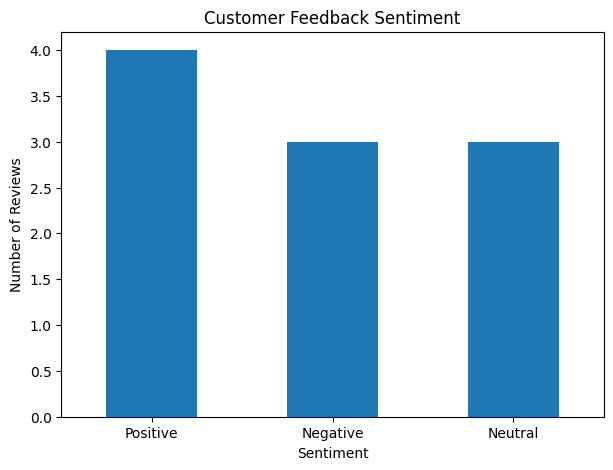

In [11]:
import matplotlib.pyplot as plt

# Count each sentiment
sentiment_counts = df["Sentiment"].value_counts()

# Create chart
plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Customer Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

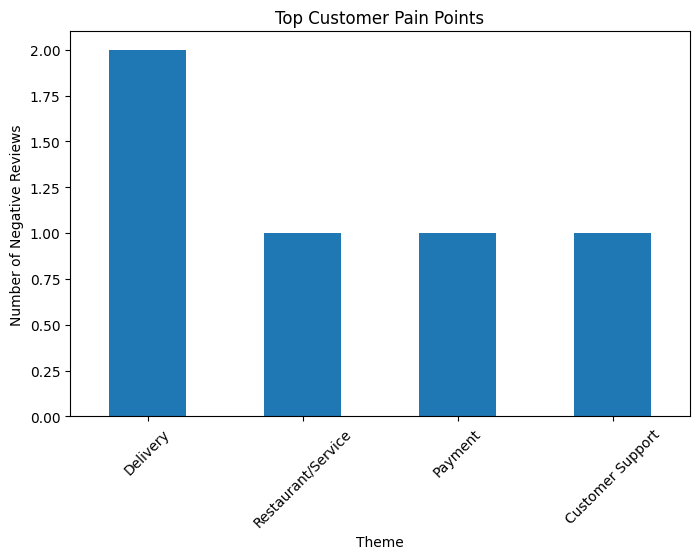

In [12]:
# Count negative reviews by theme
plt.figure(figsize=(8, 5))

pain_points.set_index("Theme")["Negative_Reviews"].plot(kind="bar")

plt.title("Top Customer Pain Points")
plt.xlabel("Theme")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=45)

plt.show()

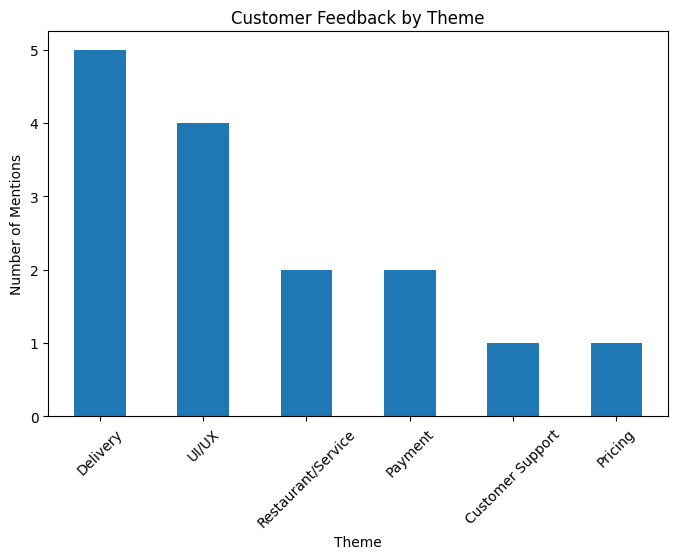

In [13]:
# Count all themes
all_themes = []

for themes in df["Theme"]:
    for theme in themes.split(", "):
        all_themes.append(theme)

theme_counts = pd.Series(all_themes).value_counts()

plt.figure(figsize=(8, 5))
theme_counts.plot(kind="bar")

plt.title("Customer Feedback by Theme")
plt.xlabel("Theme")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)

plt.show()

In [14]:
# Recommended product improvements for each theme

recommendations = {
    "Delivery": "Improve real-time order tracking and provide more accurate delivery-time estimates.",
    "Payment": "Add automatic payment retry and show clearer payment failure messages.",
    "Customer Support": "Reduce support response time and add faster self-service help options.",
    "UI/UX": "Simplify navigation and make important actions easier to find.",
    "Pricing": "Consider discounts, offers, or clearer pricing to improve perceived value.",
    "Restaurant/Service": "Improve food quality monitoring and restaurant service standards.",
    "Other": "Investigate the feedback further to identify the underlying customer problem."
}

# Add recommendations to the pain-point table
pain_points["Recommendation"] = pain_points["Theme"].map(recommendations)

# Display final recommendations
pain_points

,Theme,Negative_Reviews,Priority,Recommendation
0,Delivery,2,Medium,Improve real-time order tracking and provide m...
1,Restaurant/Service,1,Low,Improve food quality monitoring and restaurant...
2,Payment,1,Low,Add automatic payment retry and show clearer p...
3,Customer Support,1,Low,Reduce support response time and add faster se...


In [15]:
# Create a clean final report

final_report = pain_points[
    ["Theme", "Negative_Reviews", "Priority", "Recommendation"]
].copy()

final_report.columns = [
    "Theme",
    "Number of Complaints",
    "Priority",
    "Suggested Product Improvement"
]

final_report

,Theme,Number of Complaints,Priority,Suggested Product Improvement
0,Delivery,2,Medium,Improve real-time order tracking and provide m...
1,Restaurant/Service,1,Low,Improve food quality monitoring and restaurant...
2,Payment,1,Low,Add automatic payment retry and show clearer p...
3,Customer Support,1,Low,Reduce support response time and add faster se...


In [16]:
# Product Feedback Analyzer - Final Summary

total_reviews = len(df)
positive_reviews = (df["Sentiment"] == "Positive").sum()
negative_reviews = (df["Sentiment"] == "Negative").sum()
neutral_reviews = (df["Sentiment"] == "Neutral").sum()

print("========== PRODUCT FEEDBACK ANALYZER ==========")
print(f"Total Reviews      : {total_reviews}")
print(f"Positive Reviews   : {positive_reviews}")
print(f"Negative Reviews   : {negative_reviews}")
print(f"Neutral Reviews    : {neutral_reviews}")

print("\n========== TOP PAIN POINTS ==========")

for _, row in pain_points.head(3).iterrows():
    print(f"\nTheme      : {row['Theme']}")
    print(f"Complaints : {row['Negative_Reviews']}")
    print(f"Priority   : {row['Priority']}")
    print(f"Action     : {row['Recommendation']}")

print("\n===============================================")

========== PRODUCT FEEDBACK ANALYZER ==========
Total Reviews      : 10
Positive Reviews   : 4
Negative Reviews   : 3
Neutral Reviews    : 3

========== TOP PAIN POINTS ==========

Theme      : Delivery
Complaints : 2
Priority   : Medium
Action     : Improve real-time order tracking and provide more accurate delivery-time estimates.

Theme      : Restaurant/Service
Complaints : 1
Priority   : Low
Action     : Improve food quality monitoring and restaurant service standards.

Theme      : Payment
Complaints : 1
Priority   : Low
Action     : Add automatic payment retry and show clearer payment failure messages.



In [17]:
# Check the current dataset
print("Number of reviews:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 reviews:")
df.head()

Number of reviews: 10

Columns:
['Review', 'Sentiment', 'Cleaned_Review', 'Theme']

First 5 reviews:


,Review,Sentiment,Cleaned_Review,Theme
0,The food was delivered very late.,Negative,the food was delivered very late,"Delivery, Restaurant/Service"
1,The app is very easy to use.,Positive,the app is very easy to use,UI/UX
2,Payment failed twice while placing my order.,Negative,payment failed twice while placing my order,"Delivery, Payment"
3,Customer support did not respond to my complaint.,Negative,customer support did not respond to my complaint,Customer Support
4,The delivery was quick and the food was fresh.,Positive,the delivery was quick and the food was fresh,"Delivery, Restaurant/Service"


In [18]:
# Create a larger dataset of customer reviews

reviews_50 = [
    "The food arrived very late.",
    "The app is easy to use and looks great.",
    "My payment failed twice.",
    "Customer support took too long to respond.",
    "The delivery was fast and the food was fresh.",
    "The prices are too high.",
    "I could not track my order properly.",
    "The app crashed during payment.",
    "Very good service and fast delivery.",
    "The refund process is very slow.",

    "The food was cold when it arrived.",
    "The delivery person was very polite.",
    "Payment failed but money was deducted.",
    "The app interface is confusing.",
    "There are many good restaurants available.",
    "My order arrived 40 minutes late.",
    "Customer support solved my problem quickly.",
    "The delivery tracking was inaccurate.",
    "The food quality was excellent.",
    "The app keeps crashing.",

    "Prices have increased too much.",
    "I received the wrong order.",
    "Refund took several days.",
    "The payment process is smooth.",
    "Delivery was delayed again.",
    "The app is simple and convenient.",
    "Restaurant food was fresh and tasty.",
    "Customer support did not reply.",
    "I could not find the reorder option.",
    "The delivery time shown was incorrect.",

    "My payment was successful but order was not placed.",
    "The delivery was very quick.",
    "The food was disappointing.",
    "The app design is good.",
    "Prices are expensive compared to competitors.",
    "The refund was processed quickly.",
    "My order was cancelled without explanation.",
    "Tracking stopped updating.",
    "Customer support was helpful.",
    "The restaurant menu had many options.",

    "The delivery person was late.",
    "The app froze while placing an order.",
    "The food arrived hot and fresh.",
    "Payment failed several times.",
    "The order took too long to arrive.",
    "The customer service response was slow.",
    "The app is very user friendly.",
    "The prices are reasonable.",
    "I received the wrong food item.",
    "Overall I am very happy with the service."
]

# Create a new DataFrame
df = pd.DataFrame({
    "Review_ID": range(1, len(reviews_50) + 1),
    "Review": reviews_50
})

print("Total reviews:", len(df))

# Display first 10 reviews
df.head(10)

Total reviews: 50


,Review_ID,Review
0,1,The food arrived very late.
1,2,The app is easy to use and looks great.
2,3,My payment failed twice.
3,4,Customer support took too long to respond.
4,5,The delivery was fast and the food was fresh.
5,6,The prices are too high.
6,7,I could not track my order properly.
7,8,The app crashed during payment.
8,9,Very good service and fast delivery.
9,10,The refund process is very slow.


In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df[["Review", "Cleaned_Review"]].head(10)

,Review,Cleaned_Review
0,The food arrived very late.,the food arrived very late
1,The app is easy to use and looks great.,the app is easy to use and looks great
2,My payment failed twice.,my payment failed twice
3,Customer support took too long to respond.,customer support took too long to respond
4,The delivery was fast and the food was fresh.,the delivery was fast and the food was fresh
5,The prices are too high.,the prices are too high
6,I could not track my order properly.,i could not track my order properly
7,The app crashed during payment.,the app crashed during payment
8,Very good service and fast delivery.,very good service and fast delivery
9,The refund process is very slow.,the refund process is very slow


In [20]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df[["Review", "Sentiment"]].head(10)

,Review,Sentiment
0,The food arrived very late.,Negative
1,The app is easy to use and looks great.,Positive
2,My payment failed twice.,Negative
3,Customer support took too long to respond.,Neutral
4,The delivery was fast and the food was fresh.,Positive
5,The prices are too high.,Positive
6,I could not track my order properly.,Neutral
7,The app crashed during payment.,Neutral
8,Very good service and fast delivery.,Positive
9,The refund process is very slow.,Negative


In [21]:
# Define keywords for each theme
theme_keywords = {
    "Delivery": [
        "delivery", "delivered", "late", "arrived",
        "tracking", "order", "delayed"
    ],
    "Payment": [
        "payment", "pay", "paid", "refund", "money"
    ],
    "Customer Support": [
        "support", "customer service", "complaint", "reply", "response"
    ],
    "UI/UX": [
        "app", "interface", "design", "navigate",
        "navigation", "crashed", "crash", "froze"
    ],
    "Pricing": [
        "price", "prices", "expensive", "cost", "reasonable"
    ],
    "Restaurant/Service": [
        "restaurant", "food", "service", "menu", "quality"
    ]
}

# Function to detect themes
def detect_theme(text):
    found_themes = []

    for theme, keywords in theme_keywords.items():
        for keyword in keywords:
            if keyword in text:
                found_themes.append(theme)
                break

    if found_themes:
        return ", ".join(found_themes)
    else:
        return "Other"

# Apply theme detection
df["Theme"] = df["Cleaned_Review"].apply(detect_theme)

# Show results
df[["Review", "Sentiment", "Theme"]].head(15)

,Review,Sentiment,Theme
0,The food arrived very late.,Negative,"Delivery, Restaurant/Service"
1,The app is easy to use and looks great.,Positive,UI/UX
2,My payment failed twice.,Negative,Payment
3,Customer support took too long to respond.,Neutral,Customer Support
4,The delivery was fast and the food was fresh.,Positive,"Delivery, Restaurant/Service"
5,The prices are too high.,Positive,Pricing
6,I could not track my order properly.,Neutral,Delivery
7,The app crashed during payment.,Neutral,"Payment, UI/UX"
8,Very good service and fast delivery.,Positive,"Delivery, Restaurant/Service"
9,The refund process is very slow.,Negative,Payment


In [22]:
# Find negative reviews
negative_reviews = df[df["Sentiment"] == "Negative"]

# Count negative reviews for each theme
pain_point_counts = {}

for themes in negative_reviews["Theme"]:
    for theme in themes.split(", "):
        pain_point_counts[theme] = pain_point_counts.get(theme, 0) + 1

# Create a table
pain_points = pd.DataFrame(
    list(pain_point_counts.items()),
    columns=["Theme", "Negative_Reviews"]
)

# Sort from highest to lowest
pain_points = pain_points.sort_values(
    by="Negative_Reviews",
    ascending=False
)

pain_points

,Theme,Negative_Reviews
0,Delivery,5
1,Restaurant/Service,5
2,Payment,4
3,UI/UX,2
4,Pricing,1
5,Customer Support,1


In [23]:
def assign_priority(count):
    if count >= 5:
        return "High"
    elif count >= 3:
        return "Medium"
    else:
        return "Low"

pain_points["Priority"] = pain_points["Negative_Reviews"].apply(assign_priority)

pain_points

,Theme,Negative_Reviews,Priority
0,Delivery,5,High
1,Restaurant/Service,5,High
2,Payment,4,Medium
3,UI/UX,2,Low
4,Pricing,1,Low
5,Customer Support,1,Low


In [24]:
# Product recommendations for each theme

recommendations = {
    "Delivery": "Improve real-time tracking and provide more accurate delivery estimates.",
    "Payment": "Add automatic payment retry and clearer payment failure messages.",
    "Customer Support": "Reduce response time and provide faster self-service support.",
    "UI/UX": "Simplify navigation and make important actions easier to find.",
    "Pricing": "Introduce targeted discounts and improve pricing transparency.",
    "Restaurant/Service": "Improve food quality monitoring and restaurant service standards.",
    "Other": "Investigate the feedback further to identify the underlying problem."
}

# Add recommendations
pain_points["Recommendation"] = pain_points["Theme"].map(recommendations)

# Display final table
pain_points

,Theme,Negative_Reviews,Priority,Recommendation
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


In [25]:
final_report = pain_points[
    ["Theme", "Negative_Reviews", "Priority", "Recommendation"]
].copy()

final_report.columns = [
    "Theme",
    "Number of Complaints",
    "Priority",
    "Suggested Product Improvement"
]

final_report

,Theme,Number of Complaints,Priority,Suggested Product Improvement
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


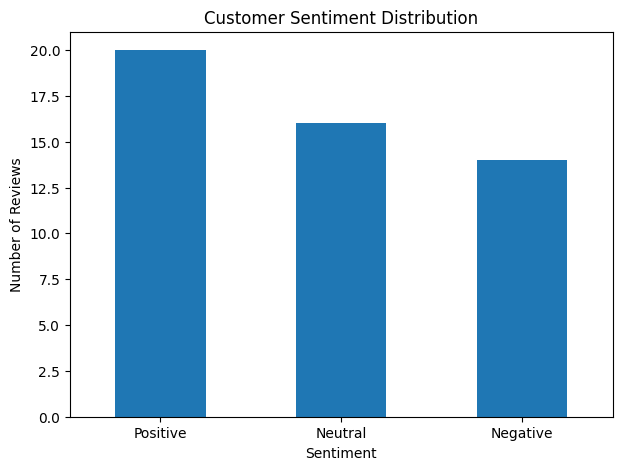

In [26]:
import matplotlib.pyplot as plt

# Sentiment distribution
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

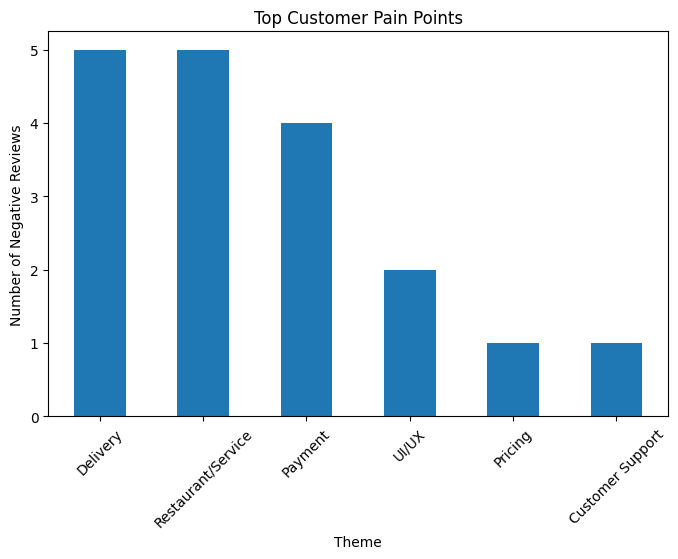

In [27]:
# Top customer pain points

plt.figure(figsize=(8, 5))

pain_points.set_index("Theme")["Negative_Reviews"].plot(kind="bar")

plt.title("Top Customer Pain Points")
plt.xlabel("Theme")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=45)

plt.show()

In [28]:
# ==============================
# PRODUCT FEEDBACK DASHBOARD
# ==============================

print("=" * 50)
print("       PRODUCT FEEDBACK ANALYZER")
print("=" * 50)

print(f"\nTotal Reviews Analyzed : {len(df)}")

print("\n--- SENTIMENT SUMMARY ---")
print(f"Positive : {(df['Sentiment'] == 'Positive').sum()}")
print(f"Negative : {(df['Sentiment'] == 'Negative').sum()}")
print(f"Neutral  : {(df['Sentiment'] == 'Neutral').sum()}")

print("\n--- TOP PAIN POINTS ---")

for _, row in pain_points.head(3).iterrows():
    print(f"\nTheme        : {row['Theme']}")
    print(f"Complaints   : {row['Negative_Reviews']}")
    print(f"Priority     : {row['Priority']}")
    print(f"Recommendation: {row['Recommendation']}")

print("\n" + "=" * 50)
print("Analysis completed successfully!")
print("=" * 50)

       PRODUCT FEEDBACK ANALYZER

Total Reviews Analyzed : 50

--- SENTIMENT SUMMARY ---
Positive : 20
Negative : 14
Neutral  : 16

--- TOP PAIN POINTS ---

Theme        : Delivery
Complaints   : 5
Priority     : High
Recommendation: Improve real-time tracking and provide more accurate delivery estimates.

Theme        : Restaurant/Service
Complaints   : 5
Priority     : High
Recommendation: Improve food quality monitoring and restaurant service standards.

Theme        : Payment
Complaints   : 4
Priority     : Medium
Recommendation: Add automatic payment retry and clearer payment failure messages.

Analysis completed successfully!


# Product Feedback Analyzer

## Project Overview

The Product Feedback Analyzer is a Python-based NLP project that analyzes customer reviews and converts unstructured feedback into actionable product insights.

## Features

- Customer review analysis
- Text preprocessing
- Sentiment classification
- Feedback theme detection
- Pain-point identification
- Priority assignment
- Product improvement recommendations
- Data visualization

## Technologies Used

- Python
- Pandas
- TextBlob
- Matplotlib
- Natural Language Processing (NLP)
- Google Colab


## Customer Reviews Dataset

This dataset contains customer reviews that will be analyzed for sentiment, themes, pain points, and product improvement opportunities.


In [35]:
df.head()

,Review_ID,Review,Cleaned_Review,Sentiment,Theme
0,1,The food arrived very late.,the food arrived very late,Negative,"Delivery, Restaurant/Service"
1,2,The app is easy to use and looks great.,the app is easy to use and looks great,Positive,UI/UX
2,3,My payment failed twice.,my payment failed twice,Negative,Payment
3,4,Customer support took too long to respond.,customer support took too long to respond,Neutral,Customer Support
4,5,The delivery was fast and the food was fresh.,the delivery was fast and the food was fresh,Positive,"Delivery, Restaurant/Service"


In [36]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Cleaned_Review"] = df["Review"].apply(clean_text)

df[["Review", "Cleaned_Review"]].head(10)

,Review,Cleaned_Review
0,The food arrived very late.,the food arrived very late
1,The app is easy to use and looks great.,the app is easy to use and looks great
2,My payment failed twice.,my payment failed twice
3,Customer support took too long to respond.,customer support took too long to respond
4,The delivery was fast and the food was fresh.,the delivery was fast and the food was fresh
5,The prices are too high.,the prices are too high
6,I could not track my order properly.,i could not track my order properly
7,The app crashed during payment.,the app crashed during payment
8,Very good service and fast delivery.,very good service and fast delivery
9,The refund process is very slow.,the refund process is very slow


In [37]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df[["Review", "Sentiment"]].head(10)

,Review,Sentiment
0,The food arrived very late.,Negative
1,The app is easy to use and looks great.,Positive
2,My payment failed twice.,Negative
3,Customer support took too long to respond.,Neutral
4,The delivery was fast and the food was fresh.,Positive
5,The prices are too high.,Positive
6,I could not track my order properly.,Neutral
7,The app crashed during payment.,Neutral
8,Very good service and fast delivery.,Positive
9,The refund process is very slow.,Negative


In [38]:
theme_keywords = {
    "Delivery": [
        "delivery", "delivered", "late", "arrived",
        "tracking", "order", "delayed"
    ],
    "Payment": [
        "payment", "pay", "paid", "refund", "money"
    ],
    "Customer Support": [
        "support", "customer service", "complaint", "reply", "response"
    ],
    "UI/UX": [
        "app", "interface", "design", "navigate",
        "navigation", "crashed", "crash", "froze"
    ],
    "Pricing": [
        "price", "prices", "expensive", "cost", "reasonable"
    ],
    "Restaurant/Service": [
        "restaurant", "food", "service", "menu", "quality"
    ]
}

def detect_theme(text):
    found_themes = []

    for theme, keywords in theme_keywords.items():
        for keyword in keywords:
            if keyword in text:
                found_themes.append(theme)
                break

    if found_themes:
        return ", ".join(found_themes)
    else:
        return "Other"

df["Theme"] = df["Cleaned_Review"].apply(detect_theme)

df[["Review", "Sentiment", "Theme"]].head(15)

,Review,Sentiment,Theme
0,The food arrived very late.,Negative,"Delivery, Restaurant/Service"
1,The app is easy to use and looks great.,Positive,UI/UX
2,My payment failed twice.,Negative,Payment
3,Customer support took too long to respond.,Neutral,Customer Support
4,The delivery was fast and the food was fresh.,Positive,"Delivery, Restaurant/Service"
5,The prices are too high.,Positive,Pricing
6,I could not track my order properly.,Neutral,Delivery
7,The app crashed during payment.,Neutral,"Payment, UI/UX"
8,Very good service and fast delivery.,Positive,"Delivery, Restaurant/Service"
9,The refund process is very slow.,Negative,Payment


In [39]:
negative_reviews = df[df["Sentiment"] == "Negative"]

pain_point_counts = {}

for themes in negative_reviews["Theme"]:
    for theme in themes.split(", "):
        pain_point_counts[theme] = pain_point_counts.get(theme, 0) + 1

pain_points = pd.DataFrame(
    list(pain_point_counts.items()),
    columns=["Theme", "Negative_Reviews"]
)

pain_points = pain_points.sort_values(
    by="Negative_Reviews",
    ascending=False
)

pain_points

,Theme,Negative_Reviews
0,Delivery,5
1,Restaurant/Service,5
2,Payment,4
3,UI/UX,2
4,Pricing,1
5,Customer Support,1


In [40]:
def assign_priority(count):
    if count >= 5:
        return "High"
    elif count >= 3:
        return "Medium"
    else:
        return "Low"

pain_points["Priority"] = pain_points["Negative_Reviews"].apply(assign_priority)

pain_points

,Theme,Negative_Reviews,Priority
0,Delivery,5,High
1,Restaurant/Service,5,High
2,Payment,4,Medium
3,UI/UX,2,Low
4,Pricing,1,Low
5,Customer Support,1,Low


In [41]:
recommendations = {
    "Delivery": "Improve real-time tracking and provide more accurate delivery estimates.",
    "Payment": "Add automatic payment retry and clearer payment failure messages.",
    "Customer Support": "Reduce response time and provide faster self-service support.",
    "UI/UX": "Simplify navigation and make important actions easier to find.",
    "Pricing": "Introduce targeted discounts and improve pricing transparency.",
    "Restaurant/Service": "Improve food quality monitoring and restaurant service standards.",
    "Other": "Investigate the feedback further to identify the underlying problem."
}

pain_points["Recommendation"] = pain_points["Theme"].map(recommendations)

pain_points

,Theme,Negative_Reviews,Priority,Recommendation
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


In [42]:
final_report = pain_points[
    ["Theme", "Negative_Reviews", "Priority", "Recommendation"]
].copy()

final_report.columns = [
    "Theme",
    "Number of Complaints",
    "Priority",
    "Suggested Product Improvement"
]

final_report

,Theme,Number of Complaints,Priority,Suggested Product Improvement
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


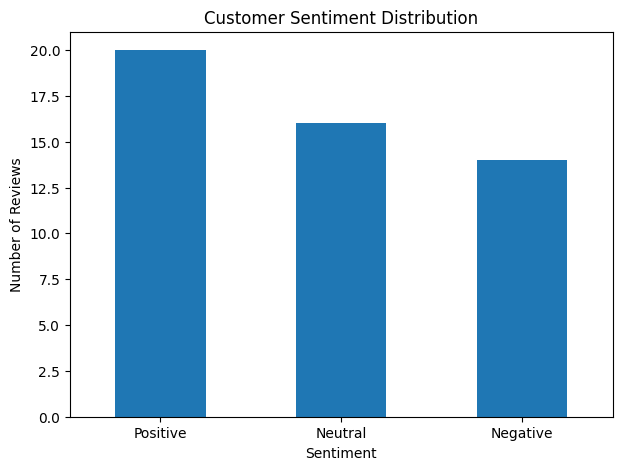

In [43]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

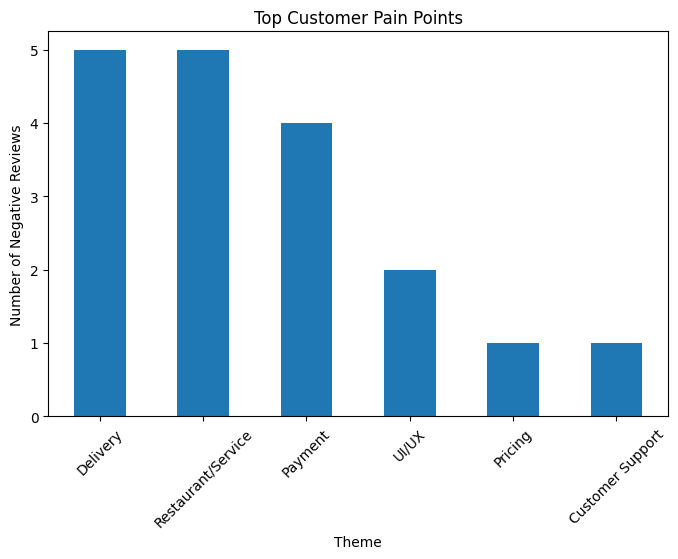

In [44]:
plt.figure(figsize=(8, 5))

pain_points.set_index("Theme")["Negative_Reviews"].plot(kind="bar")

plt.title("Top Customer Pain Points")
plt.xlabel("Theme")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=45)

plt.show()

In [45]:
print("=" * 50)
print("       PRODUCT FEEDBACK ANALYZER")
print("=" * 50)

print(f"\nTotal Reviews Analyzed : {len(df)}")

print("\n--- SENTIMENT SUMMARY ---")
print(f"Positive : {(df['Sentiment'] == 'Positive').sum()}")
print(f"Negative : {(df['Sentiment'] == 'Negative').sum()}")
print(f"Neutral  : {(df['Sentiment'] == 'Neutral').sum()}")

print("\n--- TOP PAIN POINTS ---")

for _, row in pain_points.head(3).iterrows():
    print(f"\nTheme         : {row['Theme']}")
    print(f"Complaints    : {row['Negative_Reviews']}")
    print(f"Priority      : {row['Priority']}")
    print(f"Recommendation: {row['Recommendation']}")

print("\n" + "=" * 50)
print("Analysis completed successfully!")
print("=" * 50)

       PRODUCT FEEDBACK ANALYZER

Total Reviews Analyzed : 50

--- SENTIMENT SUMMARY ---
Positive : 20
Negative : 14
Neutral  : 16

--- TOP PAIN POINTS ---

Theme         : Delivery
Complaints    : 5
Priority      : High
Recommendation: Improve real-time tracking and provide more accurate delivery estimates.

Theme         : Restaurant/Service
Complaints    : 5
Priority      : High
Recommendation: Improve food quality monitoring and restaurant service standards.

Theme         : Payment
Complaints    : 4
Priority      : Medium
Recommendation: Add automatic payment retry and clearer payment failure messages.

Analysis completed successfully!


In [46]:
print("=== PRODUCT INSIGHTS ===")

most_common_theme = pain_points.iloc[0]["Theme"]
highest_complaints = pain_points.iloc[0]["Negative_Reviews"]

print(f"\nBiggest Customer Problem: {most_common_theme}")
print(f"Number of Complaints: {highest_complaints}")

print("\nRecommended Action:")
print(pain_points.iloc[0]["Recommendation"])

=== PRODUCT INSIGHTS ===

Biggest Customer Problem: Delivery
Number of Complaints: 5

Recommended Action:
Improve real-time tracking and provide more accurate delivery estimates.


In [47]:
negative_phrases = [
    "too high",
    "too expensive",
    "failed",
    "very slow",
    "slow",
    "late",
    "delayed",
    "crashed",
    "confusing",
    "wrong order",
    "wrong food",
    "could not",
    "not reply",
    "not placed",
    "disappointing",
    "cancelled",
    "stopped updating"
]

def improve_sentiment(row):
    text = row["Cleaned_Review"]

    for phrase in negative_phrases:
        if phrase in text:
            return "Negative"

    return row["Sentiment"]

df["Improved_Sentiment"] = df.apply(improve_sentiment, axis=1)

df[["Review", "Sentiment", "Improved_Sentiment"]].head(15)

,Review,Sentiment,Improved_Sentiment
0,The food arrived very late.,Negative,Negative
1,The app is easy to use and looks great.,Positive,Positive
2,My payment failed twice.,Negative,Negative
3,Customer support took too long to respond.,Neutral,Neutral
4,The delivery was fast and the food was fresh.,Positive,Positive
5,The prices are too high.,Positive,Negative
6,I could not track my order properly.,Neutral,Negative
7,The app crashed during payment.,Neutral,Negative
8,Very good service and fast delivery.,Positive,Positive
9,The refund process is very slow.,Negative,Negative


In [48]:
print("=== IMPROVED SENTIMENT SUMMARY ===")

print(f"Positive : {(df['Improved_Sentiment'] == 'Positive').sum()}")
print(f"Negative : {(df['Improved_Sentiment'] == 'Negative').sum()}")
print(f"Neutral  : {(df['Improved_Sentiment'] == 'Neutral').sum()}")

=== IMPROVED SENTIMENT SUMMARY ===
Positive : 18
Negative : 23
Neutral  : 9


In [49]:
negative_reviews = df[df["Improved_Sentiment"] == "Negative"]

pain_point_counts = {}

for themes in negative_reviews["Theme"]:
    for theme in themes.split(", "):
        pain_point_counts[theme] = pain_point_counts.get(theme, 0) + 1

pain_points = pd.DataFrame(
    list(pain_point_counts.items()),
    columns=["Theme", "Negative_Reviews"]
)

pain_points = pain_points.sort_values(
    by="Negative_Reviews",
    ascending=False
)

pain_points

,Theme,Negative_Reviews
0,Delivery,11
2,Payment,6
1,Restaurant/Service,5
4,UI/UX,3
3,Pricing,2
5,Customer Support,2


In [50]:
def assign_priority(count):
    if count >= 5:
        return "High"
    elif count >= 3:
        return "Medium"
    else:
        return "Low"

pain_points["Priority"] = pain_points["Negative_Reviews"].apply(assign_priority)


recommendations = {
    "Delivery": "Improve real-time tracking and provide more accurate delivery estimates.",
    "Payment": "Add automatic payment retry and clearer payment failure messages.",
    "Customer Support": "Reduce response time and provide faster self-service support.",
    "UI/UX": "Simplify navigation and make important actions easier to find.",
    "Pricing": "Introduce targeted discounts and improve pricing transparency.",
    "Restaurant/Service": "Improve food quality monitoring and restaurant service standards.",
    "Other": "Investigate the feedback further to identify the underlying problem."
}

pain_points["Recommendation"] = pain_points["Theme"].map(recommendations)

pain_points

,Theme,Negative_Reviews,Priority,Recommendation
0,Delivery,11,High,Improve real-time tracking and provide more ac...
2,Payment,6,High,Add automatic payment retry and clearer paymen...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
4,UI/UX,3,Medium,Simplify navigation and make important actions...
3,Pricing,2,Low,Introduce targeted discounts and improve prici...
5,Customer Support,2,Low,Reduce response time and provide faster self-s...


In [51]:
final_report = pain_points[
    ["Theme", "Negative_Reviews", "Priority", "Recommendation"]
].copy()

final_report.columns = [
    "Theme",
    "Number of Complaints",
    "Priority",
    "Suggested Product Improvement"
]

final_report

,Theme,Number of Complaints,Priority,Suggested Product Improvement
0,Delivery,11,High,Improve real-time tracking and provide more ac...
2,Payment,6,High,Add automatic payment retry and clearer paymen...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
4,UI/UX,3,Medium,Simplify navigation and make important actions...
3,Pricing,2,Low,Introduce targeted discounts and improve prici...
5,Customer Support,2,Low,Reduce response time and provide faster self-s...


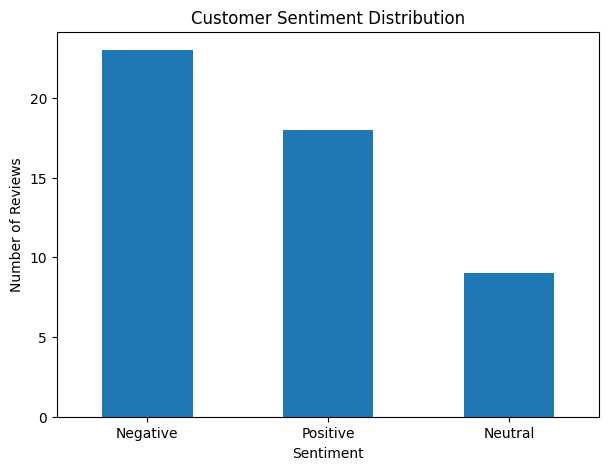

In [52]:
import matplotlib.pyplot as plt

improved_sentiment_counts = df["Improved_Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
improved_sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

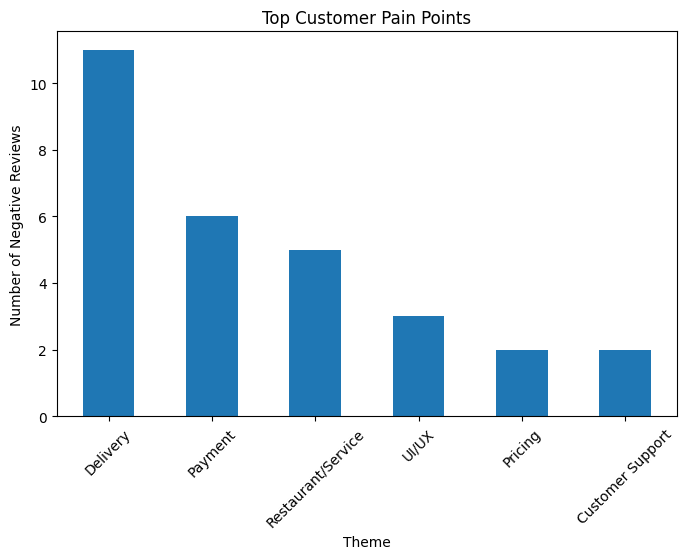

In [53]:
plt.figure(figsize=(8, 5))

pain_points.set_index("Theme")["Negative_Reviews"].plot(kind="bar")

plt.title("Top Customer Pain Points")
plt.xlabel("Theme")
plt.ylabel("Number of Negative Reviews")
plt.xticks(rotation=45)

plt.show()

In [54]:
print("=" * 60)
print("             PRODUCT FEEDBACK ANALYZER")
print("=" * 60)

total_reviews = len(df)
positive = (df["Improved_Sentiment"] == "Positive").sum()
negative = (df["Improved_Sentiment"] == "Negative").sum()
neutral = (df["Improved_Sentiment"] == "Neutral").sum()

print(f"\nTotal Reviews Analyzed : {total_reviews}")

print("\n--- SENTIMENT SUMMARY ---")
print(f"Positive : {positive}")
print(f"Negative : {negative}")
print(f"Neutral  : {neutral}")

top_problem = pain_points.iloc[0]

print("\n--- TOP CUSTOMER PROBLEM ---")
print(f"Theme       : {top_problem['Theme']}")
print(f"Complaints  : {top_problem['Negative_Reviews']}")
print(f"Priority    : {top_problem['Priority']}")

print("\n--- RECOMMENDED ACTION ---")
print(top_problem["Recommendation"])

print("\n" + "=" * 60)
print("              ANALYSIS COMPLETED")
print("=" * 60)

             PRODUCT FEEDBACK ANALYZER

Total Reviews Analyzed : 50

--- SENTIMENT SUMMARY ---
Positive : 18
Negative : 23
Neutral  : 9

--- TOP CUSTOMER PROBLEM ---
Theme       : Delivery
Complaints  : 11
Priority    : High

--- RECOMMENDED ACTION ---
Improve real-time tracking and provide more accurate delivery estimates.

              ANALYSIS COMPLETED


## Key Business Insights

### Overall Findings

The Product Feedback Analyzer analyzed 50 customer reviews and identified the main areas affecting customer experience.

- 23 reviews were classified as Negative.
- 18 reviews were classified as Positive.
- 9 reviews were classified as Neutral.
- Delivery was identified as the highest-priority customer pain point.
- Delivery received 11 negative mentions.

### Product Recommendation

The analysis recommends improving real-time delivery tracking and providing more accurate delivery time estimates.

### Business Value

This project demonstrates how customer feedback can be transformed into actionable product insights using Python, NLP, sentiment analysis, keyword-based theme detection, and data visualization.


In [56]:
df[["Review"]].to_csv("customer_reviews.csv", index=False)

print("Sample CSV file created successfully!")

Sample CSV file created successfully!


In [59]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

uploaded_df = pd.read_csv(file_name)

print("File uploaded successfully!")
print(f"Number of reviews: {len(uploaded_df)}")

uploaded_df.head()

Saving customer_reviews.csv to customer_reviews (1).csv
File uploaded successfully!
Number of reviews: 50


,Review
0,The food arrived very late.
1,The app is easy to use and looks great.
2,My payment failed twice.
3,Customer support took too long to respond.
4,The delivery was fast and the food was fresh.


In [58]:
from google.colab import files

files.download("customer_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
uploaded_df.head()

,Review
0,The food arrived very late.
1,The app is easy to use and looks great.
2,My payment failed twice.
3,Customer support took too long to respond.
4,The delivery was fast and the food was fresh.


In [61]:
uploaded_df["Cleaned_Review"] = uploaded_df["Review"].apply(clean_text)

uploaded_df[["Review", "Cleaned_Review"]].head(10)

,Review,Cleaned_Review
0,The food arrived very late.,the food arrived very late
1,The app is easy to use and looks great.,the app is easy to use and looks great
2,My payment failed twice.,my payment failed twice
3,Customer support took too long to respond.,customer support took too long to respond
4,The delivery was fast and the food was fresh.,the delivery was fast and the food was fresh
5,The prices are too high.,the prices are too high
6,I could not track my order properly.,i could not track my order properly
7,The app crashed during payment.,the app crashed during payment
8,Very good service and fast delivery.,very good service and fast delivery
9,The refund process is very slow.,the refund process is very slow


In [62]:
uploaded_df["Sentiment"] = uploaded_df["Cleaned_Review"].apply(get_sentiment)

uploaded_df[["Review", "Sentiment"]].head(10)

,Review,Sentiment
0,The food arrived very late.,Negative
1,The app is easy to use and looks great.,Positive
2,My payment failed twice.,Negative
3,Customer support took too long to respond.,Neutral
4,The delivery was fast and the food was fresh.,Positive
5,The prices are too high.,Positive
6,I could not track my order properly.,Neutral
7,The app crashed during payment.,Neutral
8,Very good service and fast delivery.,Positive
9,The refund process is very slow.,Negative


In [63]:
uploaded_df["Theme"] = uploaded_df["Cleaned_Review"].apply(detect_theme)

uploaded_df[["Review", "Sentiment", "Theme"]].head(15)

,Review,Sentiment,Theme
0,The food arrived very late.,Negative,"Delivery, Restaurant/Service"
1,The app is easy to use and looks great.,Positive,UI/UX
2,My payment failed twice.,Negative,Payment
3,Customer support took too long to respond.,Neutral,Customer Support
4,The delivery was fast and the food was fresh.,Positive,"Delivery, Restaurant/Service"
5,The prices are too high.,Positive,Pricing
6,I could not track my order properly.,Neutral,Delivery
7,The app crashed during payment.,Neutral,"Payment, UI/UX"
8,Very good service and fast delivery.,Positive,"Delivery, Restaurant/Service"
9,The refund process is very slow.,Negative,Payment


In [64]:
uploaded_negative = uploaded_df[
    uploaded_df["Sentiment"] == "Negative"
]

uploaded_pain_counts = {}

for themes in uploaded_negative["Theme"]:
    for theme in themes.split(", "):
        uploaded_pain_counts[theme] = uploaded_pain_counts.get(theme, 0) + 1

uploaded_pain_points = pd.DataFrame(
    list(uploaded_pain_counts.items()),
    columns=["Theme", "Negative_Reviews"]
)

uploaded_pain_points = uploaded_pain_points.sort_values(
    by="Negative_Reviews",
    ascending=False
)

uploaded_pain_points

,Theme,Negative_Reviews
0,Delivery,5
1,Restaurant/Service,5
2,Payment,4
3,UI/UX,2
4,Pricing,1
5,Customer Support,1


In [65]:
uploaded_pain_points["Priority"] = (
    uploaded_pain_points["Negative_Reviews"]
    .apply(assign_priority)
)

uploaded_pain_points["Recommendation"] = (
    uploaded_pain_points["Theme"]
    .map(recommendations)
)

uploaded_pain_points

,Theme,Negative_Reviews,Priority,Recommendation
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


In [66]:
uploaded_final_report = uploaded_pain_points[
    ["Theme", "Negative_Reviews", "Priority", "Recommendation"]
].copy()

uploaded_final_report.columns = [
    "Theme",
    "Number of Complaints",
    "Priority",
    "Suggested Product Improvement"
]

uploaded_final_report

,Theme,Number of Complaints,Priority,Suggested Product Improvement
0,Delivery,5,High,Improve real-time tracking and provide more ac...
1,Restaurant/Service,5,High,Improve food quality monitoring and restaurant...
2,Payment,4,Medium,Add automatic payment retry and clearer paymen...
3,UI/UX,2,Low,Simplify navigation and make important actions...
4,Pricing,1,Low,Introduce targeted discounts and improve prici...
5,Customer Support,1,Low,Reduce response time and provide faster self-s...


In [67]:
print("=" * 60)
print("       PRODUCT FEEDBACK ANALYZER - FINAL TEST")
print("=" * 60)

print(f"\nReviews analyzed: {len(uploaded_df)}")

print("\nSentiment:")
print(uploaded_df["Sentiment"].value_counts())

print("\nTop Customer Pain Points:")

for _, row in uploaded_pain_points.head(3).iterrows():
    print(f"\nTheme: {row['Theme']}")
    print(f"Complaints: {row['Negative_Reviews']}")
    print(f"Priority: {row['Priority']}")
    print(f"Recommendation: {row['Recommendation']}")

print("\n" + "=" * 60)
print("             TEST COMPLETED")
print("=" * 60)

       PRODUCT FEEDBACK ANALYZER - FINAL TEST

Reviews analyzed: 50

Sentiment:
Sentiment
Positive    20
Neutral     16
Negative    14
Name: count, dtype: int64

Top Customer Pain Points:

Theme: Delivery
Complaints: 5
Priority: High
Recommendation: Improve real-time tracking and provide more accurate delivery estimates.

Theme: Restaurant/Service
Complaints: 5
Priority: High
Recommendation: Improve food quality monitoring and restaurant service standards.

Theme: Payment
Complaints: 4
Priority: Medium
Recommendation: Add automatic payment retry and clearer payment failure messages.

             TEST COMPLETED


# Product Feedback Analyzer

## Overview

An NLP-based Python project that analyzes customer feedback and converts unstructured reviews into actionable product insights.

## What This Project Does

- Analyzes customer reviews
- Cleans and preprocesses text
- Performs sentiment analysis
- Detects feedback themes
- Identifies customer pain points
- Assigns problem priorities
- Generates product recommendations
- Visualizes customer feedback
- Supports CSV file uploads

## Technologies

- Python
- Pandas
- TextBlob
- Natural Language Processing (NLP)
- Matplotlib
- Google Colab


## 1. Dataset
## 2. Text Preprocessing
## 3. Sentiment Analysis
## 4. Theme Detection
## 5. Pain Point Analysis
## 6. Product Recommendations
## 7. Data Visualization
## 8. Final Dashboard
## 9. CSV Upload & Analysis
## 10. Business Insights
